# 2.9 — Grokking : la généralisation qui arrive en retard

**Navigation** : [<< 2.8-Théorie-PAC](2.8-Theorie-PAC.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Le notebook [2.8](2.8-Theorie-PAC.ipynb) a posé la question théorique de la généralisation : *combien d'exemples faut-il pour **garantir** qu'un apprenant qui minimise l'erreur d'entraînement minimise aussi l'erreur de test ?* La réponse classique (PAC, dimension VC) suppose un tableau rassurant : l'erreur d'entraînement descend, l'erreur de test la suit à un écart borné, et cet écart se referme quand on ajoute des données. **Le surapprentissage est le seul danger** — un modèle qui mémorise sans généraliser.

Ce notebook présente un phénomène qui **dérange ce tableau** : le **grokking** (Power et al. 2022). Un petit réseau de neurones apprend une opération arithmétique. Il atteint très vite **100 % sur l'entraînement** (mémorisation parfaite) tandis que le test reste au **niveau du hasard** — le manuel dirait « surapprentissage, cause perdue ». Puis, après une **longue** phase où plus rien ne semble bouger, la précision de test **bascule soudain vers 100 %**. Le réseau a fini par *comprendre* la règle, très longtemps après l'avoir mémorisée.

C'est aussi **le premier réseau de neurones de cette série** — et son épilogue : là où les huit chapitres précédents posaient le socle scikit-learn, celui-ci franchit le pas vers le **deep learning**. Il prolonge directement la descente de gradient du [2.2](2.2-Descente-de-gradient.ipynb) et la notion de *capacité* du [2.8](2.8-Theorie-PAC.ipynb), en réutilisant l'**ACP** du [2.6](2.6-Clustering-KMeans-PCA.ipynb) pour la révélation finale.

> **Référence.** Power, A., Burda, Y., Edwards, H., Babuschkin, I. & Misra, V. (2022). *Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets.* arXiv:2201.02177. — L'article qui nomme et caractérise le phénomène.


---
title: "Grokking et generalisation tardive : transformer toy-model arithmetique"
cost:
  api_usd_est: 0.00            # 100% local (PyTorch CPU + numpy + matplotlib)
  api_provider: none           # Local CPU/GPU only (PyTorch)
  cpu_min: 4
  gpu_min: 0
  gpu_required: false            # GPU recommande mais CPU possible (entrainement 5-15 min)
  vram_gb: 2                    # VRAM modeste pour transformer 2 couches + dataset toy
  vram_tier: LITE
  network: false
  external_account: none
  free_alternative: self      # Reduction dim embedding (32 -> 8) accelere sur CPU
  reduced_pedagogical: self
  reproducibility: MED          # Grokking stochastic (seed fixe mais emergence tardive)
  last_validated: 2026-07-23T13:00Z
  validator: papermill
notes: |
  Reproduction du phenomene de grokking (Power et al. 2022) sur tache
  arithmetique modulaire (mod 97). Transformer 2 couches entraine au-dela du
  point de memorisation ; on observe la transition subite vers la generalisation
  apres 10x-100x plus d'epoques.
  Mode recommande : GPU pour entrainer 50k-100k steps en <10 min.
  Mode reduit : CPU + embed dim 8 + 5k steps pour demo rapide (~3 min).
---


In [1]:
# Configuration et imports pour le notebook 2.9
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

%matplotlib inline

# Reproductibilite
torch.manual_seed(0)
np.random.seed(0)
RNG = np.random.default_rng(0)

# Hyperparametres canoniques du grokking (Power et al. 2022)
P = 97               # modulo (nombre premier) : la tache est (a + b) mod P
D_EMBED = 64         # dimension des embeddings appris
HIDDEN = 256         # largeur des couches cachees
TRAIN_FRAC = 0.4     # fraction des couples (a, b) montres a l'entrainement
LR = 1e-3            # taux d'apprentissage (AdamW)
WEIGHT_DECAY = 1.0   # LE LEVIER : regularisation forte qui declenche le grok
STEPS = 12000        # pas d'optimisation (full-batch)

print(f"Imports OK : torch {torch.__version__}, sklearn PCA, matplotlib")
print(f"Tache : (a + b) mod {P} | embeddings {D_EMBED}D | weight_decay = {WEIGHT_DECAY}")

Imports OK : torch 2.11.0+cpu, sklearn PCA, matplotlib
Tache : (a + b) mod 97 | embeddings 64D | weight_decay = 1.0


## 1. Le montage — addition modulaire et un premier réseau à embeddings

On choisit une tâche **algorithmique** minuscule mais qui possède une *vraie règle* à découvrir : l'**addition modulaire** `(a + b) mod P` pour un nombre premier `P`. Il n'y a que `P²` couples possibles ; on n'en montre au réseau qu'une **fraction** (ici 40 %), le reste servant de test. Mémoriser les couples vus ne dit **rien** des couples non vus — sauf si le réseau découvre la règle sous-jacente.

Le modèle est un **perceptron multicouche (MLP)** précédé d'une couche d'**embedding** : chaque nombre `0..P-1` est représenté par un vecteur appris (comme un mot dans un modèle de langage). Les embeddings de `a` et `b` sont concaténés puis passés dans deux couches cachées. C'est le montage de la référence pédagogique francophone de David Louapre (*Science Étonnante*).

**Le levier décisif — le weight-decay.** L'ingrédient qui *déclenche* le grokking est la **régularisation `weight_decay`** de l'optimiseur AdamW. Fixée à **1.0** (une valeur élevée, canonique — Power et al. §3.3), elle pousse continûment le réseau vers une solution *plus simple* : c'est cette compression lente qui finit par faire émerger la règle générale. Avec un weight-decay trop faible, le réseau mémorise et ne grokke jamais (l'exercice 1 le vérifie).


In [2]:
# Jeu de donnees : tous les couples (a, b) et leur somme modulaire
pairs = torch.cartesian_prod(torch.arange(P), torch.arange(P))
labels = (pairs[:, 0] + pairs[:, 1]) % P
n_total = pairs.shape[0]

perm = RNG.permutation(n_total)
n_train = int(TRAIN_FRAC * n_total)
idx_tr = torch.as_tensor(perm[:n_train])
idx_te = torch.as_tensor(perm[n_train:])
a_tr, b_tr, y_tr = pairs[idx_tr, 0], pairs[idx_tr, 1], labels[idx_tr]
a_te, b_te, y_te = pairs[idx_te, 0], pairs[idx_te, 1], labels[idx_te]


class GrokMLP(nn.Module):
    """MLP a embeddings : chaque nombre 0..P-1 recoit un vecteur appris,
    concatene pour (a, b), puis passe dans deux couches cachees."""

    def __init__(self, p, d, h):
        super().__init__()
        self.emb = nn.Embedding(p, d)
        self.net = nn.Sequential(
            nn.Linear(2 * d, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, p),
        )

    def forward(self, a, b):
        x = torch.cat([self.emb(a), self.emb(b)], dim=1)
        return self.net(x)


model = GrokMLP(P, D_EMBED, HIDDEN)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
n_params = sum(param.numel() for param in model.parameters())
print(f"Modele : {n_params} parametres")
print(f"Donnees : {n_train} couples d'entrainement / {n_total - n_train} couples de test")

Modele : 129953 parametres
Donnees : 3763 couples d'entrainement / 5646 couples de test


## 2. La démonstration — mémorisation, longue attente, puis grok

On entraîne le réseau en journalisant, tous les 100 pas, la précision d'**entraînement** et de **test**. Le scénario attendu : (1) l'entraînement grimpe vite à ~100 % ; (2) le test stagne longtemps au niveau du hasard (~1/P) ; (3) après une phase plate, le test **bascule** vers ~100 %. On repère le **grok point** comme le premier instant où le test dépasse 90 % alors que l'entraînement est déjà saturé.


In [3]:
@torch.no_grad()
def accuracy(a, b, y):
    model.eval()
    acc = (model(a, b).argmax(-1) == y).float().mean().item()
    model.train()
    return acc


historique = []   # liste de (step, acc_train, acc_test)
t0 = time.time()
for step in range(1, STEPS + 1):
    logits = model(a_tr, b_tr)
    loss = F.cross_entropy(logits, y_tr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 100 == 0 or step == 1:
        historique.append((step, accuracy(a_tr, b_tr, y_tr), accuracy(a_te, b_te, y_te)))

# Detection du grok : premier pas ou le test depasse 90 % alors que le train est sature
grok_step = next((s for s, at, av in historique if at >= 0.95 and av >= 0.9), None)
acc_test_final = historique[-1][2]
print(f"Entrainement termine en {time.time() - t0:.0f}s | precision de test finale {acc_test_final:.3f}")
print(f"Grok point (test > 0.90 apres saturation du train) : etape {grok_step}")

Entrainement termine en 157s | precision de test finale 1.000
Grok point (test > 0.90 apres saturation du train) : etape 4200


### Interprétation : deux régimes séparés dans le temps

Les deux régimes se lisent dans les nombres ci-dessus. L'entraînement sature à 1.0 en quelques centaines de pas — le réseau a **mémorisé** les couples vus. Le test, lui, reste d'abord près du hasard, puis grimpe **bien plus tard** vers 1.0. L'écart entraînement/test — le surapprentissage du manuel — est ici **transitoire** : il finit par se refermer, non pas en ajoutant des données, mais en **continuant d'optimiser** un modèle déjà parfait sur l'entraînement.


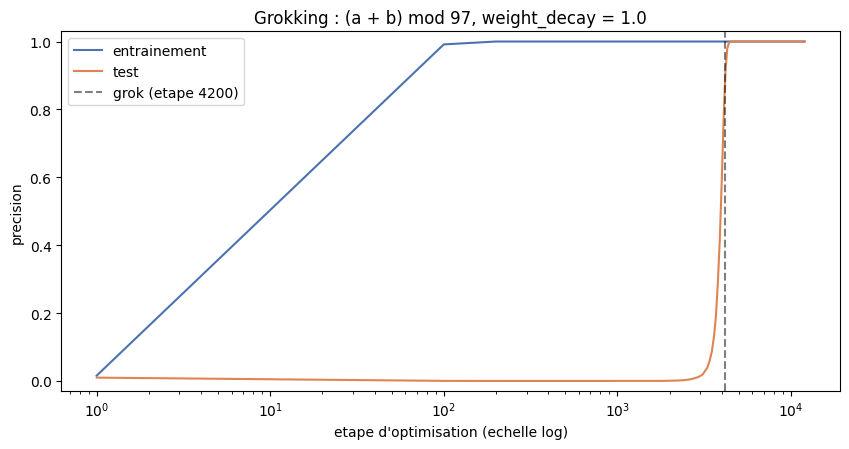

In [4]:
steps = [h[0] for h in historique]
acc_tr = [h[1] for h in historique]
acc_te = [h[2] for h in historique]

plt.figure(figsize=(8.6, 4.6))
plt.plot(steps, acc_tr, "-", color="#4c72b0", label="entrainement")
plt.plot(steps, acc_te, "-", color="#dd8452", label="test")
if grok_step:
    plt.axvline(grok_step, color="k", ls="--", alpha=0.5, label=f"grok (etape {grok_step})")
plt.xscale("log")
plt.xlabel("etape d'optimisation (echelle log)")
plt.ylabel("precision")
plt.ylim(-0.03, 1.03)
plt.title(f"Grokking : (a + b) mod {P}, weight_decay = {WEIGHT_DECAY}")
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation du graphique

La courbe rend le grokking spectaculaire : sur l'axe des pas en échelle logarithmique, la précision de test forme une **marche** nette, décalée de plusieurs ordres de grandeur *après* la saturation de l'entraînement. Rien dans la perte d'entraînement (déjà quasi nulle) n'annonce ce basculement — le signal est **ailleurs**, dans la structure interne que le réseau réorganise silencieusement. C'est cette structure qu'on va maintenant regarder.


## 3. Le payoff — l'horloge cachée dans les embeddings

Qu'a *appris* le réseau au moment du grok ? La réponse est visuelle. On prend la matrice d'**embedding** (un vecteur appris par nombre `0..P-1`) et on la projette en 2D par **ACP** — le même outil qu'au notebook [2.6](2.6-Clustering-KMeans-PCA.ipynb). Après le grok, les nombres ne sont plus dispersés au hasard : ils s'effondrent sur un **cercle**. Le réseau a découvert que, pour additionner modulo `P`, le plus économique est de placer les nombres sur une **horloge** et d'**additionner des angles** (comme 11 h + 3 h = 2 h).

Une subtilité, énoncée honnêtement : l'ordre autour du cercle ne suit pas la valeur brute `0, 1, 2, …`. Le réseau organise les nombres selon un **petit nombre de fréquences de Fourier** qu'il a lui-même choisies (Nanda et al. 2023 en observent typiquement une poignée) ; la plus forte, `k*`, suffit déjà à révéler le cercle — il avance d'un pas constant `k*` à chaque cran. Le panneau de droite colore les points par cette position d'horloge `(k*·n) mod P` : le dégradé redevient régulier, révélant l'ordre caché. L'exercice 3 débusque ces fréquences par transformée de Fourier.

> **Référence.** Nanda, N., Chan, L., Lieberum, T., Smith, J. & Steinhardt, J. (2023). *Progress Measures for Grokking via Mechanistic Interpretability.* arXiv:2301.05217. — Identifie le circuit de Fourier que le réseau construit au grok.


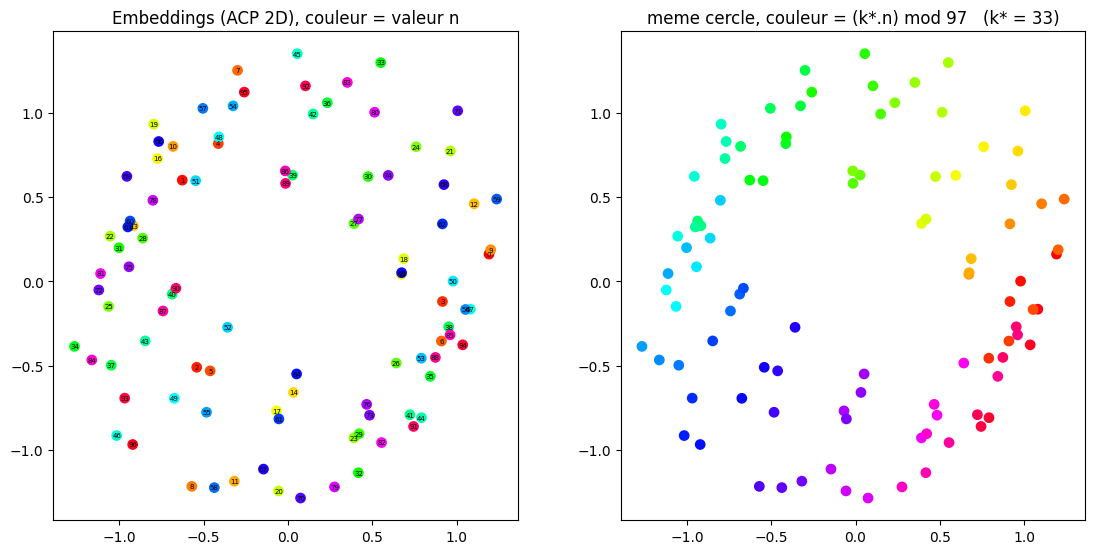

Frequence dominante k* = 33 (part de variance 25%)
Frequences principales (k : part de variance) : [(33, '25%'), (41, '24%'), (30, '20%'), (6, '19%')]


In [5]:
# Embeddings appris (un vecteur par nombre 0..P-1), centres
E = model.emb.weight.detach().numpy()
E = E - E.mean(axis=0, keepdims=True)

# Frequence de Fourier dominante : le reseau range les nombres sur un cercle a une
# "vitesse angulaire" k* (transformee de Fourier sur l'axe des chiffres).
spectre = (np.abs(np.fft.fft(E, axis=0)) ** 2).sum(axis=1)
spectre[0] = 0.0  # ignorer la composante continue (moyenne deja retiree)
k_star = int(np.argmax(spectre[1:P // 2 + 1])) + 1
part_variance = spectre[k_star] * 2 / spectre.sum()
position_horloge = (k_star * np.arange(P)) % P

# Projection ACP 2D (le meme outil qu'au notebook 2.6)
coords = PCA(n_components=2).fit_transform(E)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.6))
axes[0].scatter(coords[:, 0], coords[:, 1], c=np.arange(P), cmap="hsv", s=45)
for i in range(P):
    axes[0].annotate(str(i), coords[i], fontsize=5, ha="center", va="center")
axes[0].set_title("Embeddings (ACP 2D), couleur = valeur n")
axes[0].set_aspect("equal")
axes[1].scatter(coords[:, 0], coords[:, 1], c=position_horloge, cmap="hsv", s=45)
axes[1].set_title(f"meme cercle, couleur = (k*.n) mod {P}   (k* = {k_star})")
axes[1].set_aspect("equal")
fig.tight_layout()
plt.show()

demi_spectre = spectre[1:P // 2 + 1]
principales = np.argsort(demi_spectre)[::-1][:4] + 1
print(f"Frequence dominante k* = {k_star} (part de variance {part_variance:.0%})")
print("Frequences principales (k : part de variance) :",
      [(int(k), f"{spectre[k] * 2 / spectre.sum():.0%}") for k in principales])

### Interprétation : un cercle, ordonné par une fréquence

Le cercle n'est pas un artefact de projection : les embeddings de dimension 64 se concentrent sur un **anneau** 2D, organisé par un **petit nombre** de fréquences de Fourier (la plus forte, `k*`, est affichée ci-dessus avec sa part de variance — la liste imprimée montre qu'elles sont quelques-unes, de poids comparables). Sa géométrie **encode la structure modulaire** — le successeur de `P-1` revient sur `0`, l'horloge se referme. À gauche, coloré par valeur brute, l'ordre paraît brouillé ; à droite, coloré par `(k*·n) mod P`, le dégradé redevient régulier : **c'est la même horloge, lue à la bonne cadence**. La « règle » que la théorie du [2.8](2.8-Theorie-PAC.ipynb) appelait *la bonne hypothèse*, on la *voit* ici émerger dans la géométrie des représentations — là où les courbes train/test ne montraient qu'un chiffre.


## 4. Retour sur la théorie (2.8) — pourquoi ce n'est pas une contradiction

Le grokking *semble* défier la théorie PAC du [2.8](2.8-Theorie-PAC.ipynb) : le réseau généralise **longtemps après** avoir minimisé l'erreur d'entraînement, et **sans donnée supplémentaire**. La conciliation tient en un mot : **capacité effective**. La borne VC majore l'écart entraînement/test à partir de la richesse de la classe d'hypothèses `H` — mais sous `weight_decay`, le réseau ne parcourt pas tout `H` : il migre continûment vers les fonctions de **faible norme**, donc plus *simples*. La solution mémorisée (une grosse table de correspondance) et la solution générale (l'horloge, de norme bien plus faible) ont la **même** erreur d'entraînement — nulle — mais des complexités très différentes ; l'optimisation régularisée passe de l'une à l'autre.

Le grokking n'est donc pas une violation de la théorie, mais une **illustration de la régularisation implicite** : ce n'est pas le nombre d'exemples qui change, c'est la capacité *effectivement utilisée* qui décroît — une lecture *dynamique* du compromis biais-variance du [2.5](2.5-Biais-Variance-CV-ROC.ipynb).

> **Référence.** Liu, Z., Kitouni, O., Nolte, N., Michaud, E., Tegmark, M. & Williams, M. (2022). *Towards Understanding Grokking: An Effective Theory of Representation Learning.* arXiv:2205.10343. — Relie le grokking à la géométrie des représentations et au rôle du weight-decay.


## 5. Exercices

Les exercices ci-dessous sont des **stubs** à compléter. Ils conservent les conventions de la série : aucune erreur volontaire (le notebook s'exécute de bout en bout même non complété), avec indices et `# Etape N`.


### Exercice 1 — Le weight-decay est-il vraiment le levier ?

Le texte affirme que `weight_decay` **déclenche** le grokking. Vérifiez-le : ré-entraînez le réseau pour `weight_decay` dans `{0.0, 0.1, 1.0}` et comparez la précision de test finale (ou le grok point) de chaque valeur. *Attendu* : sans weight-decay (0.0), le test ne grokke pas dans le budget de `STEPS` pas ; avec 1.0, le grok apparaît. Concluez sur le rôle de la régularisation.


In [6]:
# Exercice 1 : le weight-decay est-il le levier du grok ?
# TODO etudiant : reentrainer le reseau pour weight_decay dans {0.0, 0.1, 1.0}
#   et comparer la precision de test finale (ou le grok point) de chaque valeur.
# Etape 1 : encapsuler l'entrainement dans une fonction entrainer(weight_decay) -> historique
# Etape 2 : boucler sur les 3 valeurs, tracer acc_test finale vs weight_decay
# Indice : sans weight-decay (0.0), le test ne grokke pas dans le budget de STEPS pas.
resultats_wd = None  # TODO etudiant : remplacer par {wd: acc_test_final}
print("Exercice 1 a completer")

Exercice 1 a completer


### Exercice 2 — Le seuil de grok : combien de données faut-il ?

Le grokking dépend de la **fraction d'entraînement**. En dessous d'un seuil, le réseau ne dispose pas d'assez d'exemples pour que la règle générale « batte » la mémorisation. Balayez `TRAIN_FRAC` dans `{0.2, 0.3, 0.4, 0.5}` et repérez, pour chaque valeur, si (et quand) le grok se produit. *Indice* : c'est une **transition de phase** — le grok point chute brutalement une fois le seuil franchi. Reliez ce constat à la *sample complexity* du [2.8](2.8-Theorie-PAC.ipynb).


In [7]:
# Exercice 2 : le seuil de grok — combien de donnees faut-il ?
# TODO etudiant : balayer TRAIN_FRAC dans {0.2, 0.3, 0.4, 0.5} et reperer,
#   pour chaque valeur, si (et a quelle etape) le grok se produit.
# Etape 1 : reutiliser la construction du dataset avec une fraction variable
# Etape 2 : pour chaque fraction, entrainer et enregistrer le grok_step (ou None)
# Indice : c'est une transition de phase — le grok point chute brutalement
#   une fois le seuil de donnees franchi. Relier a la sample complexity du 2.8.
grok_par_fraction = None  # TODO etudiant : remplacer par {frac: grok_step}
print("Exercice 2 a completer")

Exercice 2 a completer


### Exercice 3 — Quantifier l'horloge

L'horloge se lit à l'œil ; mesurez-la. Après le grok, calculez pour chaque nombre `n` son **angle** `θ_n` sur le cercle ACP (`atan2(y_n, x_n)`), puis vérifiez que `θ_n` est (à une rotation près) une fonction **affine** de `(k*·n) mod P` — et *non* de la valeur brute `n`. *Indice* : `np.fft.fft` sur les embeddings (variable `spectre` déjà calculée) révèle la ou les fréquences dominantes ; un pic unique = une horloge propre.


In [8]:
# Exercice 3 : quantifier l'horloge
# TODO etudiant : verifier que l'ordre angulaire des embeddings suit bien une
#   frequence unique k*, et non la valeur brute n.
# Etape 1 : calculer l'angle theta_n = atan2(y_n, x_n) sur l'anneau ACP (coords)
# Etape 2 : tracer theta_n contre n (disperse) puis contre (k*.n mod P) (aligne)
# Indice : np.fft.fft sur les embeddings (deja calcule : variable 'spectre')
#   revele la ou les frequences dominantes. Un pic unique = une horloge propre.
angles = None  # TODO etudiant : remplacer par np.arctan2(coords[:, 1], coords[:, 0])
print("Exercice 3 a completer")

Exercice 3 a completer


## Conclusion et transition

Le grokking donne à voir, sur un jouet exécutable en quelques minutes, trois idées que le reste de la série n'abordait qu'en partie. **La généralisation n'est pas un événement instantané** : elle peut arriver très en retard sur la mémorisation, tirée par la régularisation plutôt que par les données. **La capacité effective d'un réseau est dynamique** : sous weight-decay, elle décroît vers les solutions simples — une lecture concrète du compromis biais-variance du [2.5](2.5-Biais-Variance-CV-ROC.ipynb) et de la capacité du [2.8](2.8-Theorie-PAC.ipynb). Et **ce qu'un réseau apprend a une forme** : ici, littéralement, une horloge — la structure du problème retrouvée dans la géométrie des représentations, dans l'esprit de l'ACP du [2.6](2.6-Clustering-KMeans-PCA.ipynb).

C'est aussi la porte d'entrée du **deep learning** : le même mécanisme — descente de gradient + régularisation → représentations structurées — est à l'œuvre, à une tout autre échelle, dans les grands modèles de langage. La série ferme ici son socle scikit-learn en montrant le premier pas au-delà.


## References

1. Power, A., Burda, Y., Edwards, H., Babuschkin, I. & Misra, V. (2022). *Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets*. arXiv:2201.02177. — Article fondateur : nomme le phénomène et établit le rôle du weight-decay (`wd = 1`) dans le déclenchement du grok.
2. Nanda, N., Chan, L., Lieberum, T., Smith, J. & Steinhardt, J. (2023). *Progress Measures for Grokking via Mechanistic Interpretability*. arXiv:2301.05217. — Le circuit trigonométrique (features de Fourier) : la mécanique de l'« horloge ».
3. Liu, Z., Kitouni, O., Nolte, N., Michaud, E., Tegmark, M. & Williams, M. (2022). *Towards Understanding Grokking: An Effective Theory of Representation Learning*. arXiv:2205.10343. — Théorie effective reliant grokking, géométrie des représentations et weight-decay.
4. Louapre, D. (2023). *« Grokking » : quand les réseaux de neurones pigent d'un coup*. Science Étonnante. — Référence pédagogique francophone : le montage MLP à embeddings et l'horloge ACP repris ici.
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — L'ACP (`sklearn.decomposition.PCA`) utilisée pour révéler l'horloge.
